In [1]:
import os
import glob

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import MDAnalysis as mda
from tqdm import tqdm
from numpy import linalg as LA
from MDAnalysis.analysis import align
from matplotlib.ticker import FuncFormatter

%run ~/.mpl_358.py

import pyemma

In [2]:
df_all = pd.read_pickle("./df_comp_kmeans_mod.pkl")
df_all

,sys_name,frame,n_res,dist,n_contacts,rmsd,rmsd_nsp10,rmsd_nsp16,labels,mod
0,comp_0,0,415,32.605477,143,1.270958,1.157980,1.061589,453,1
1,comp_0,1,415,32.323373,144,1.266247,1.135788,1.180746,228,0
2,comp_0,2,415,31.932924,156,1.251338,1.298619,1.130007,448,0
3,comp_0,3,415,32.521470,149,1.232570,1.067588,1.155031,59,0
4,comp_0,4,415,32.193099,157,1.497461,1.652155,1.348938,183,0
...,...,...,...,...,...,...,...,...,...,...
83995,comp_100,3995,415,39.647390,107,10.644501,5.009146,2.698992,283,4
83996,comp_100,3996,415,39.943104,114,10.607467,4.521076,2.744293,102,4
83997,comp_100,3997,415,39.952250,113,10.840326,4.824111,2.710605,72,4
83998,comp_100,3998,415,40.436388,108,10.780112,4.630009,2.768572,72,4


In [3]:
X[np.argmin(f)//len(f), np.argmin(f)%len(f)], Y[np.argmin(f)//len(f), np.argmin(f)%len(f)]

NameError: name 'X' is not defined

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Helvetica


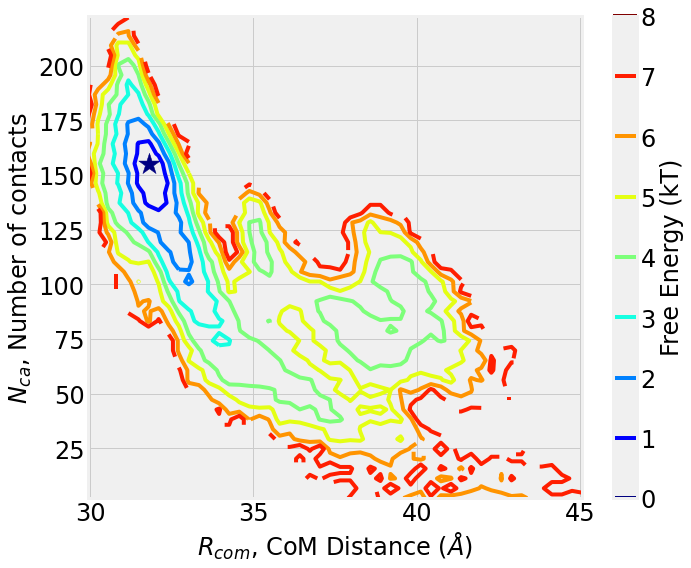

In [4]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(10,8))
divider = make_axes_locatable(ax)
path_ind = [0, 17, 7]

x, y, z = pyemma.plots.plots2d.get_histogram(
    df_all['dist'], df_all['n_contacts'],
    nbins=50, weights=None,
    avoid_zero_count=False)
f = pyemma.plots.plots2d._to_free_energy(z, minener_zero=False) * 1.
f -= np.min(f)
[X, Y] = np.meshgrid(x, y)
CT = ax.contour(X, Y, f, cmap='jet')
ax.scatter(X[np.argmin(f)//len(f), np.argmin(f)%len(f)], 
           Y[np.argmin(f)//len(f), np.argmin(f)%len(f)], 
           marker='*', s=500, c='navy')

# cax_CT = divider.append_axes("top", size="7%", pad="10%")
# cbar_ = fig.colorbar(CT, cax=cax_CT, orientation='horizontal') 
cbar_ = fig.colorbar(CT) 
cbar_.ax.set_ylabel(r'Free Energy (kT)')


ax.set_xlabel(r'$R_{com}$, CoM Distance ($\AA$)')
ax.set_ylabel(r'$N_{ca}$, Number of contacts')

fig.tight_layout()
fig.savefig(f'dist_contact.png', dpi=300, bbox_inches='tight')



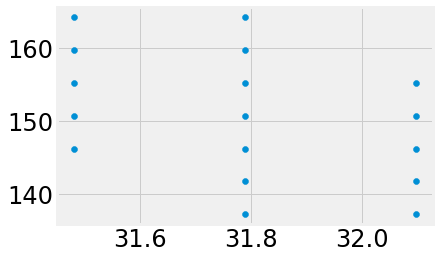

In [12]:
plt.scatter(X[f <= 1], Y[f <= 1])

In [10]:
X[f < 1], Y[f < 1]

(array([31.78875813, 32.0973023 , 31.78875813, 32.0973023 , 31.48021396,
        31.78875813, 32.0973023 , 31.48021396, 31.78875813, 32.0973023 ,
        31.48021396, 31.78875813, 32.0973023 , 31.48021396, 31.78875813,
        31.48021396, 31.78875813]),
 array([137.25, 137.25, 141.75, 141.75, 146.25, 146.25, 146.25, 150.75,
        150.75, 150.75, 155.25, 155.25, 155.25, 159.75, 159.75, 164.25,
        164.25]))

In [13]:
df_nat = df_all[(df_all.dist > min(X[f < 1])) & (df_all.dist < max(X[f < 1])) & (df_all.n_contacts > min(Y[f < 1])) &(df_all.n_contacts < max(Y[f < 1]))]

<AxesSubplot:>

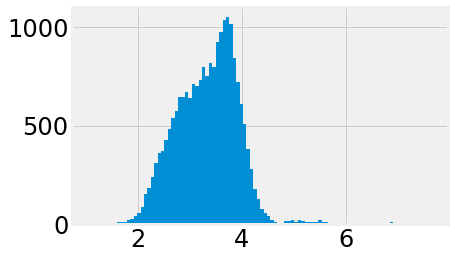

In [14]:
df_nat.rmsd.hist(bins=100)

In [15]:
df_nat.rmsd.describe()

count    21050.000000
mean         3.350118
std          0.634649
min          1.066377
25%          2.908471
50%          3.389605
75%          3.755906
max          7.632506
Name: rmsd, dtype: float64